# Aula 08/04

## Algoritmo Genético (Sem binário)

### Kariny e Wandra

### Função g06 => (x1 − 10)³ + (x2 − 20)³ \
restrição 1: -(x1 - 5)² - (x2 - 5)² + 100 <= 0 \
restrição 2: (x1 - 6)² + (x2 − 5)² - 82.81 <= 0

intervalo: 13 ≤ x1 ≤ 100 e 0 ≤ x2 ≤ 100. \
A solução ótima é = (14.09500000000000064,0.8429607892154795668, −6961.81387558015)

In [94]:
#f(x) = (x1 − 10)³ + (x2 − 20)³
def g06(x1, x2):
    return (x1 - 10)**3 + (x2 - 20)**3

#restrição 1: -(x1 - 5)² - (x2 - 5)² + 100 <= 0
def g1(x1, x2):
    return -(x1 - 5)**2 - (x2 - 5)**2 + 100

#restrição 2: (x1 - 6)² + (x2 − 5)² - 82.81 <= 0
def g2(x1, x2):
    return (x1 - 6)**2 + (x2 - 5)**2 - 82.81

def fitness(x1, x2):
  y = g06(x1, x2)
  y_g1 = g1(x1, x2)
  y_g2 = g2(x1, x2)

  if y_g1 > 0:
      y += y_g1 * 10000
  if y_g2 > 0:
      y += y_g2 * 10000

  return(x1, x2, y)

MIN_PLOT = -7000
MAX_PLOT = 0
MIN_VAL_X1 = 13
MAX_VAL_X1 = 100
MIN_VAL_X2 = 0
MAX_VAL_X2 = 100
TAXA_MUT = 0.3
TAM_POP = 50
GERACAO = 100

### Função g11 => f(x) = x1² + (x2 − 1)² com a restrição => (x2 - x1²) = 0

intervalo: −1 ≤ x1 ≤ 1 e −1 ≤ x2 ≤ 1. \
A solução ótima é: x∗ = (−0.707036070037170616,0.500000004333606807) \
onde f(x∗) = 0.7499.


In [95]:
# f(x) = x1² + (x2 − 1)²
def g11(x1, x2):
    return x1**2 + (x2 - 1)**2

# restrição: (x2 - x1²) = 0
def h1(x1, x2):
    return abs(x2 - x1**2)

# def fitness(x1, x2):
#   y = g11(x1, x2)
#   y_h1 = h1(x1, x2)

#   if y_h1 > 10e-6:
#       y += y_h1

#   return(x1, x2, y)

# MIN_PLOT = 0.8
# MAX_PLOT = 10000
# TAM_POP = 100
# MIN_VAL_X1 = -1
# MAX_VAL_X1 = 1
# MIN_VAL_X2 = -1
# MAX_VAL_X2 = 1
# TAXA_MUT = 0.5
# TAM_POP = 50
# GERACAO = 100

### Gerar Populaçao Inicial

In [96]:
import random
def gerar_populacao_inicial():
  populacao = []
  for x in range(TAM_POP):
    x1 = random.uniform(MIN_VAL_X1, MAX_VAL_X1)
    x2 = random.uniform(MIN_VAL_X2, MAX_VAL_X2)
    tupla_individuo = fitness(x1, x2)
    populacao.append(tupla_individuo)

  return populacao

print(gerar_populacao_inicial())

[(62.28968328715187, 7.654965323370733, 31068762.498637956), (67.9557010605407, 58.23624770806454, 66148536.71678456), (66.90460545387145, 55.04182765730003, 61534748.45277468), (24.948377420107256, 58.821558389370885, 31791760.308387637), (95.67474047479159, 91.73660445122712, 155817909.3511629), (40.964303045308185, 98.18764113837241, 98743962.75954008), (41.308678158031285, 45.41193142510631, 28017269.525419645), (35.201101324505004, 18.318086564115976, 9488657.83132808), (29.52554191971446, 26.369994905789863, 9280880.573256522), (23.520607284061278, 68.08170075247568, 42148255.83086029), (55.36199320104374, 95.86098561600122, 106625064.20748514), (86.55504371867266, 72.61101442753021, 110369830.63166362), (24.725067150707286, 84.85144182669936, 66716648.14245411), (37.100955028368375, 10.700670638886056, 9188670.926315926), (50.7794665404547, 87.33550092421417, 87388372.03547901), (69.53769868924653, 80.55728852675405, 97064450.35135311), (55.39174849966997, 80.52674263350404, 809

### Calcular o valor do fitness (y)

In [97]:
def calcular_fitness(pop):
    nova_pop = []

    for x1, x2, _ in pop: 
      nova_pop.append(fitness(x1, x2))
    return nova_pop


### Roleta

In [98]:
import random

def roleta(pop):
    ys = [ind[2] for ind in pop] #lista de fitness dos indivíduos

    # inverte minimização - vira maximização
    pior = max(ys)
    fitness_inv = []
    for y in ys:
        fitness_inv.append(pior - y)

    soma = sum(fitness_inv)

    # normalização
    prob = []
    for f in fitness_inv:
        prob.append(f / soma)

    # roleta (intervalos)
    intervalo = 0
    roleta = []
    for p in prob:
        intervalo += p
        roleta.append(intervalo)

    # sorteio do intervalo
    r = random.random()

    for i, valor in enumerate(roleta):
        if valor >= r:
            return pop[i] #retorna o indivíduo selecionado (pai)

### Cruzamento BLX-α

In [99]:
def cruzamento_BLXa(pai1, pai2):
    a = 0.5 

    # distancias
    dist_x1 = abs(pai1[0] - pai2[0])
    dist_x2 = abs(pai1[1] - pai2[1])

    min_x1 = min(pai1[0], pai2[0]) - a*dist_x1
    max_x1 = max(pai1[0], pai2[0]) + a*dist_x1

    min_x2 = min(pai1[1], pai2[1]) - a*dist_x2
    max_x2 = max(pai1[1], pai2[1]) + a*dist_x2
    
    filho1_x1 =random.uniform(min_x1, max_x1)
    if filho1_x1 < MIN_VAL_X1:
        filho1_x1 = MIN_VAL_X1
    if filho1_x1 > MAX_VAL_X1:
        filho1_x1 = MAX_VAL_X1

    filho1_x2 = random.uniform(min_x2, max_x2)
    if filho1_x2 < MIN_VAL_X2:
        filho1_x2 = MIN_VAL_X2
    if filho1_x2 > MAX_VAL_X2:
        filho1_x2 = MAX_VAL_X2

    filho2_x1 = random.uniform(min_x1, max_x1)
    if filho2_x1 < MIN_VAL_X1:
        filho2_x1 = MIN_VAL_X1
    if filho2_x1 > MAX_VAL_X1:
        filho2_x1 = MAX_VAL_X1

    filho2_x2 = random.uniform(min_x2, max_x2)
    if filho2_x2 < MIN_VAL_X2:
        filho2_x2 = MIN_VAL_X2
    if filho2_x2 > MAX_VAL_X2:
        filho2_x2 = MAX_VAL_X2

    return filho1_x1, filho1_x2, filho2_x1, filho2_x2


### Cruzamento BLX-αβ
O intervalo de geração é assimétrico \
Ele puxa mais para o melhor pai

In [100]:
def cruzamento_BLXab(pai1, pai2):
    a = 0.75
    b = 0.25

    # distancias
    dist_x1 = abs(pai1[0] - pai2[0])
    dist_x2 = abs(pai1[1] - pai2[1])

    # define melhor e pior Y
    if pai1[2] < pai2[2]:
        melhor = pai1
        pior = pai2
    else:
        melhor = pai2
        pior = pai1

    # x1
    # u ∈ (X[i] − αd,Y [i] + βd)
    if melhor[0] <= pior[0]:
        min_x1 = melhor[0] - a * dist_x1
        max_x1 = pior[0] + b * dist_x1
    else: #u ∈ (Y [i] − βd,X[i] + αd)
        min_x1 = pior[0] - b * dist_x1
        max_x1 = melhor[0] + a * dist_x1

    # x2
    if melhor[1] <= pior[1]:
        min_x2 = melhor[1] - a * dist_x2
        max_x2 = pior[1] + b * dist_x2
    else:
        min_x2 = pior[1] - b * dist_x2
        max_x2 = melhor[1] + a * dist_x2
    
    filho1_x1 = random.uniform(min_x1, max_x1)
    if filho1_x1 < MIN_VAL_X1:
        filho1_x1 = MIN_VAL_X1
    if filho1_x1 > MAX_VAL_X1:
        filho1_x1 = MAX_VAL_X1

    filho1_x2 = random.uniform(min_x2, max_x2)
    if filho1_x2 < MIN_VAL_X2:
        filho1_x2 = MIN_VAL_X2
    if filho1_x2 > MAX_VAL_X2:
        filho1_x2 = MAX_VAL_X2

    filho2_x1 = random.uniform(min_x1, max_x1)
    if filho2_x1 < MIN_VAL_X1:
        filho2_x1 = MIN_VAL_X1
    if filho2_x1 > MAX_VAL_X1:
        filho2_x1 = MAX_VAL_X1

    filho2_x2 = random.uniform(min_x2, max_x2)
    if filho2_x2 < MIN_VAL_X2:
        filho2_x2 = MIN_VAL_X2
    if filho2_x2 > MAX_VAL_X2:
        filho2_x2 = MAX_VAL_X2

    return filho1_x1, filho1_x2, filho2_x1, filho2_x2

### Gerar nova população

In [101]:
def gerar_filhos(pop):
    nova_pop = []
    while len(nova_pop) < TAM_POP - 1:
        # seleciona os pais com roleta
        pai1 = roleta(pop)
        pai2 = roleta(pop)

        # gera os filhos com cruzamento
        filho1_x1, filho1_x2, filho2_x1, filho2_x2 = cruzamento_BLXab(pai1, pai2)
        
        # calcula o fitness dos filhos
        filho1 = fitness(filho1_x1, filho1_x2)
        filho2 = fitness(filho2_x1, filho2_x2)

        # adiciona os filhos na nova população
        nova_pop.append(filho1)
        if len(nova_pop) < TAM_POP - 1:
            nova_pop.append(filho2)

    return nova_pop

### Mutação

In [102]:
def mutacao(pop, sigma=0.05):
    pop_mutada = []

    for x1, x2, y in pop:

        # muta x1
        if random.random() < TAXA_MUT:
            x1 = x1 + random.gauss(0, sigma)
            x1 = max(MIN_VAL_X1, min(MAX_VAL_X1, x1))

        # muta x2
        if random.random() < TAXA_MUT:
            x2 = x2 + random.gauss(0, sigma)
            x2 = max(MIN_VAL_X2, min(MAX_VAL_X2, x2))

        pop_mutada.append((x1, x2, fitness(x1, x2)[2]))

    return pop_mutada

### Elitismo

In [103]:
def elitismo(pop, k=1):
    # ordena pelo fitness (y)
    pop_ordenada = sorted(pop, key=lambda ind: ind[2])
    return pop_ordenada[:k]

### Main

In [104]:
def main():
    pop = gerar_populacao_inicial()

    print(f"Geração 0: Melhor indivíduo: {min(pop, key=lambda ind: ind[2])}")

    pop = gerar_filhos(pop)
    print(f"Geração 1: Melhor indivíduo: {min(pop, key=lambda ind: ind[2])}")

    for geracao in range(GERACAO):
        elite = elitismo(pop)

        filhos = gerar_filhos(pop)
        filhos = mutacao(filhos)

        # mantém tamanho fixo
        pop = filhos[:TAM_POP - 1] + elite

        melhor = min(pop, key=lambda ind: ind[2])
        print(f"Geração {geracao+2}: Melhor indivíduo: {melhor}")
  
  
main()

Geração 0: Melhor indivíduo: (17.06214332515573, 6.620438479220169, 419825.4635344018)
Geração 1: Melhor indivíduo: (13, 22.95582041528086, 2886067.6924896725)
Geração 2: Melhor indivíduo: (13, 14.346263415905808, 535272.6781899668)
Geração 3: Melhor indivíduo: (13, 14.346263415905808, 535272.6781899668)
Geração 4: Melhor indivíduo: (13, 0, 102027)
Geração 5: Melhor indivíduo: (14.181560747669534, 0.009670511940271466, 82397.96214873131)
Geração 6: Melhor indivíduo: (13.042975114182008, 10.448171091856784, 55436.52332042313)
Geração 7: Melhor indivíduo: (13.816723574828622, 0.39183381380809923, 2818.5464252764923)
Geração 8: Melhor indivíduo: (13.761361155465949, 0.1980866620361061, -1038.6505145112806)
Geração 9: Melhor indivíduo: (13.761361155465949, 0.1980866620361061, -1038.6505145112806)
Geração 10: Melhor indivíduo: (13.761361155465949, 0.1980866620361061, -1038.6505145112806)
Geração 11: Melhor indivíduo: (13.761361155465949, 0.1980866620361061, -1038.6505145112806)
Geração 12: 

In [105]:
def executar_uma_vez():
    pop = gerar_populacao_inicial()
    melhores = []

    for _ in range(GERACAO):
        elite = elitismo(pop)

        filhos = gerar_filhos(pop)
        filhos = mutacao(filhos)

        pop = filhos + elite

        melhor = min(pop, key=lambda ind: ind[2])
        melhores.append(melhor[2])

    return melhores

[3738141.939096059, 426519.0334391094, 312175.52666242153, 37333.65038544512, 759.8821108968987, 759.8821108968987, -1383.9234733008914, -1752.4189965630594, -3367.6949591500816, -3367.6949591500816, -3367.6949591500816, -5113.1508994916785, -5113.1508994916785, -5113.1508994916785, -6641.204825464501, -6641.204825464501, -6641.204825464501, -6641.204825464501, -6641.204825464501, -6641.204825464501, -6641.204825464501, -6641.204825464501, -6641.204825464501, -6641.204825464501, -6757.559806723294, -6757.559806723294, -6757.559806723294, -6757.559806723294, -6804.784728644107, -6882.659264691213, -6882.659264691213, -6882.659264691213, -6882.659264691213, -6882.659264691213, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.449194471896, -6939.4491944718

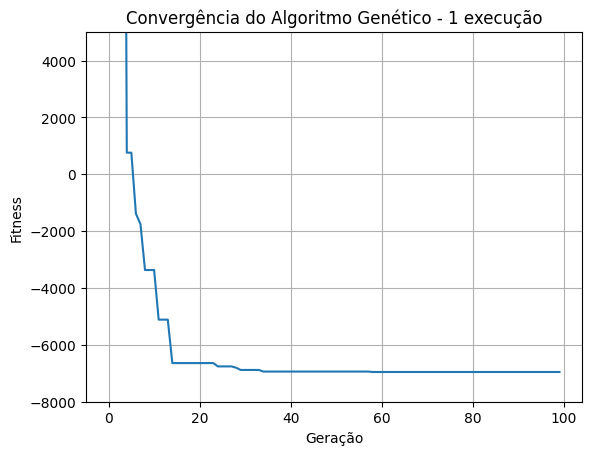


===== ESTATÍSTICAS =====
Média: -6669.360603397377
Melhor: -6950.187891167902
Pior: -5973.4341754348825
Desvio padrão: 297.2785895961694


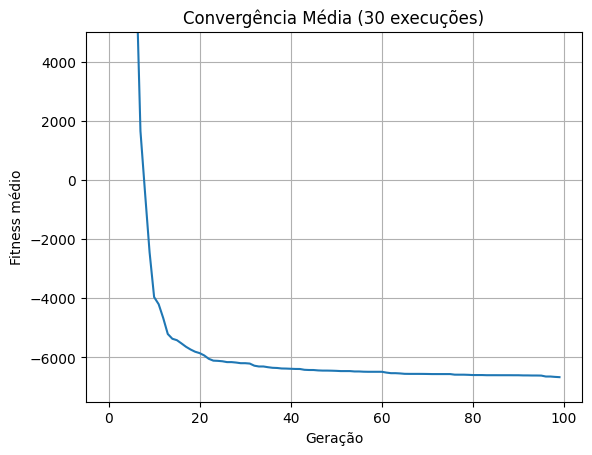

In [106]:
import matplotlib.pyplot as plt
import numpy as np

def main():
    # -------- Gráfico de 1 execução --------
    melhores = executar_uma_vez()
    print(melhores)
    plt.plot(melhores)
    plt.ylim(-8000, 5000)
    plt.xlabel("Geração")
    plt.ylabel("Fitness")
    plt.title("Convergência do Algoritmo Genético - 1 execução")
    plt.grid()
    plt.show()

    # -------- 30 execuções --------
    resultados = []
    todas_execucoes = []

    for _ in range(30):
        melhores = executar_uma_vez()
        resultados.append(min(melhores))
        todas_execucoes.append(melhores)

    # -------- Estatísticas --------
    print("\n===== ESTATÍSTICAS =====")
    print("Média:", np.mean(resultados))
    print("Melhor:", np.min(resultados))
    print("Pior:", np.max(resultados))
    print("Desvio padrão:", np.std(resultados))

    # -------- Gráfico médio --------
    media = np.mean(todas_execucoes, axis=0)

    plt.plot(media)
    plt.ylim(-7500, 5000)
    plt.xlabel("Geração")
    plt.ylabel("Fitness médio")
    plt.title("Convergência Média (30 execuções)")
    plt.grid()
    plt.show()


main()